In [1]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()

In [84]:
df.shape

(37249, 2)

In [85]:
df.sample()['clean_comment'].values

array(['remember donnie when shows you can ask him for slurpee and lottery tickets '],
      dtype=object)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [87]:
df.isnull().sum() #observing missing value

clean_comment    100
category           0
dtype: int64

In [88]:
df[df['clean_comment'].isna()] #showing in where there is missing value

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [89]:
df[df['clean_comment'].isna()]['category'].value_counts()

category
0    100
Name: count, dtype: int64

In [90]:
df.duplicated().sum()

np.int64(449)

In [91]:
df[df.duplicated()] #These are the duplicates in data

,clean_comment,category
375,,0
392,,0
605,NaN,0
617,aurum mom,0
651,,0
...,...,...
37111,NaN,0
37125,hari,0
37158,top kek,1
37234,this part series minute videos focusing each d...,1


In [92]:
df.drop_duplicates(inplace=True)

In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df[(df['clean_comment'].str.strip()=='')] #if there is any new line or not

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [95]:
df=df[~(df['clean_comment'].str.strip()=='')]

In [96]:
df['clean_comment']=df['clean_comment'].str.lower()
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [97]:
df[df['clean_comment'].apply(lambda x: str(x).endswith(' ') or str(x).startswith(' '))] #finding any kind of data that starts with empty space or ends with empty space

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [98]:
df['clean_comment']=df['clean_comment'].str.strip() #removing starting and ending whitespace from the 'clean_comment' column

In [99]:
df[df['clean_comment'].apply(lambda x: str(x).endswith(' ') or str(x).startswith(' '))] #finding any kind of data that starts with empty space or ends with empty space

,clean_comment,category


In [100]:
df['clean_comment'] = df['clean_comment'].fillna('')

In [101]:
# Identify comments containing URLs
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]
# Display the comments containing URLs
comments_with_urls.head()

,clean_comment,category


In [ ]:
comments_with_newline=df[df['clean_comment'].str.contains('\n')] #identifying comments containing new line characters
comments_with_newline.head()
#later url is not removed. It need to be handeled later

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [ ]:
df['clean_comment'] = df['clean_comment'].fillna('').str.replace(url_pattern, '', regex=True)  


In [69]:
#Removing new line charecters from the 'clean_comment' column
df['clean_comment']=df['clean_comment'].str.replace('\n',' ',regex=True)
# regex=True means the pattern you provide is treated as a Regular Expression (regex) pattern instead of a plain text string.
# Regex (Regular Expression) = a pattern used to search or match text.




In [70]:
comments_with_newline_remaining=df[df['clean_comment'].str.contains('\n')] #again checking comments containing new line characters
comments_with_newline_remaining.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars


#EDA

<Axes: xlabel='category', ylabel='count'>

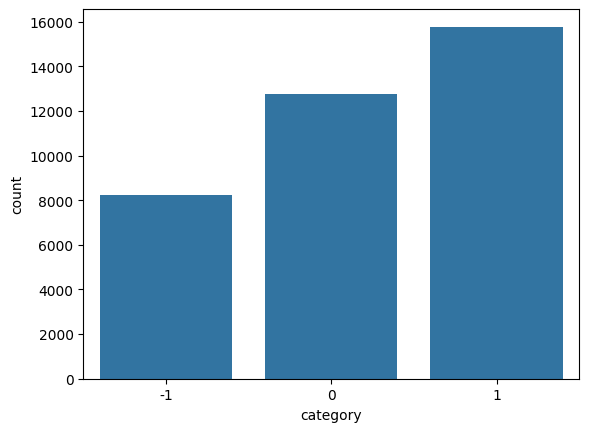

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
#distribution of classes
sns.countplot(data=df,x="category")


In [72]:
#frequency distribution of sentiments
df['category'].value_counts(normalize=True).mul(100).round(2)

category
 1    42.86
 0    34.71
-1    22.42
Name: proportion, dtype: float64

In [73]:
df['word_count']=df['clean_comment'].apply(lambda x:len(x.split())) #how many words each comment contains and storing that count in a new column

In [74]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
33637,like indian extended family family diverse pol...,-1,16,9,156,0
15020,know baba ramdev product shit but still popula...,1,39,20,328,0
25749,unexpected,1,1,0,10,0
30796,want meme,0,2,1,14,0
10236,great leader dear mister modi,1,5,0,29,0


In [75]:
df['word_count'].describe()

count    36794.000000
mean        20.089716
std         39.073140
min          0.000000
25%          5.000000
50%          9.000000
75%         20.000000
max        893.000000
Name: word_count, dtype: float64

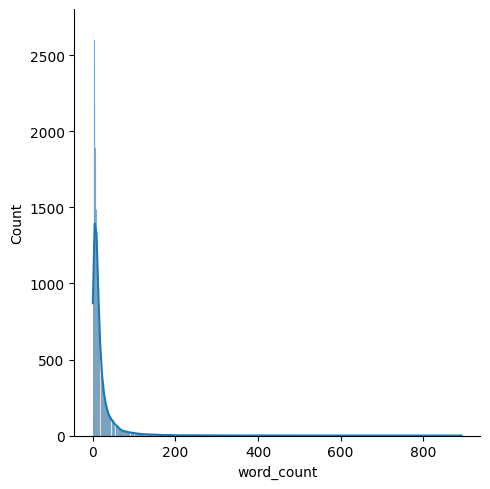

In [76]:
sns.displot(df['word_count'],kde=True) #That means neutral comments has more data

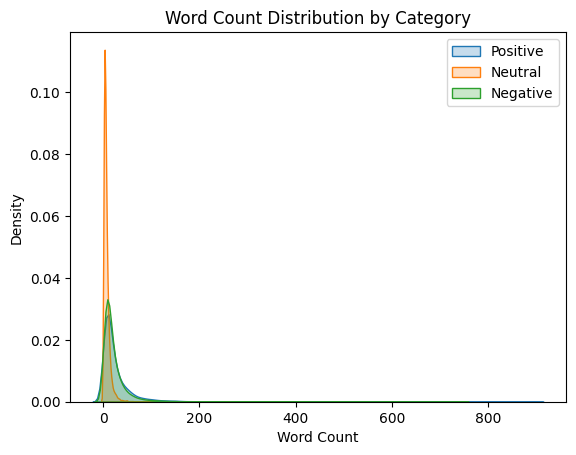

In [77]:
#More advanced plot
# Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['word_count'], label='Positive', fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['word_count'], label='Neutral', fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['word_count'], label='Negative', fill=True)

# Add title and labels
plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

# Add a legend
plt.legend()

# Show the plot
plt.show()

<Axes: ylabel='word_count'>

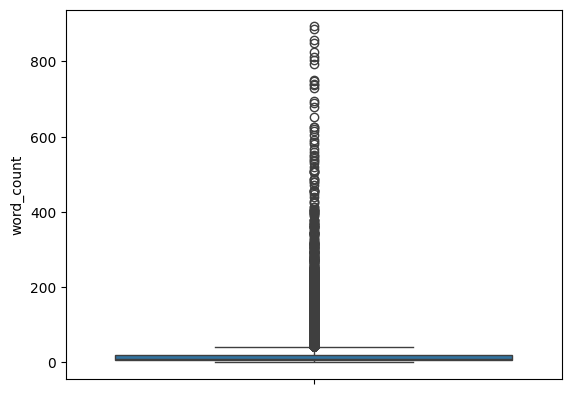

In [78]:
sns.boxplot(df['word_count'])

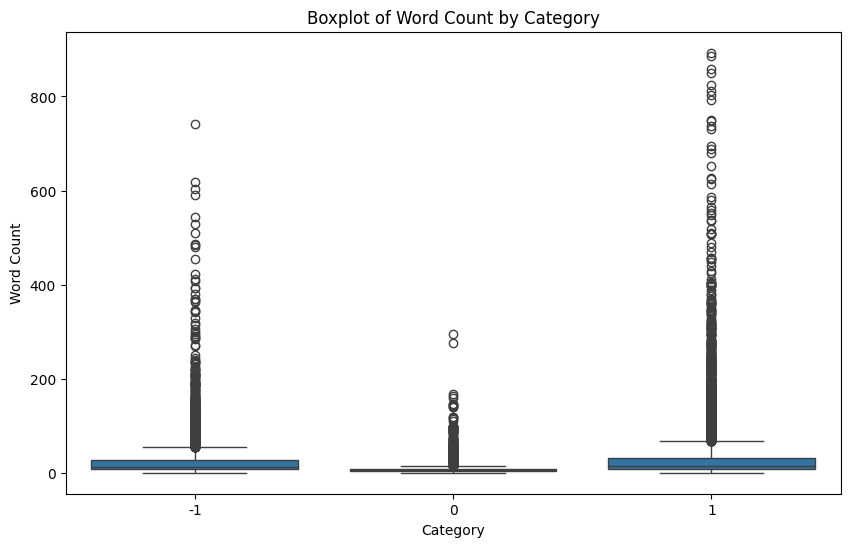

In [79]:
# Create a boxplot for the 'word_count' column categorized by 'category'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='word_count')

plt.title('Boxplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')

plt.show()

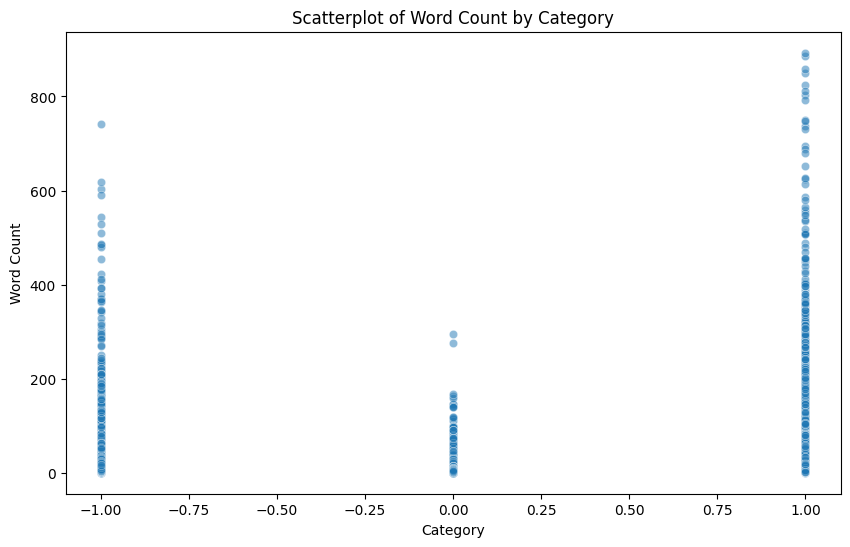

In [80]:
# Create a scatterplot between 'category' and 'wordcount'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='category', y='word_count', alpha=0.5)

plt.title('Scatterplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')

plt.show()

<Axes: xlabel='category', ylabel='word_count'>

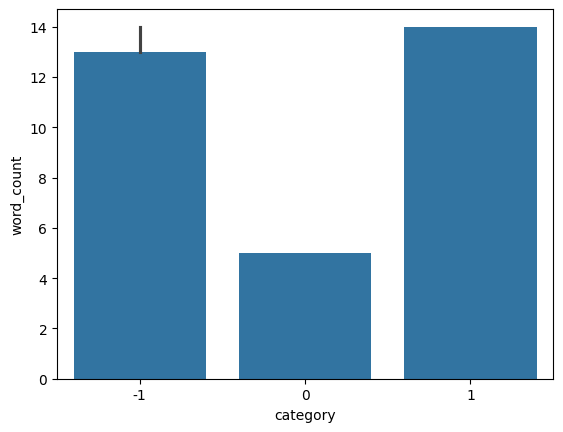

In [81]:
#median word counts among sentiments
sns.barplot(df,x='category',y='word_count',estimator='median')

doing more preprocessing

In [82]:
from nltk.corpus import stopwords

# Download NLTK stopwords if not already downloaded
import nltk
nltk.download('stopwords')

# Define the list of English stopwords
stop_words = set(stopwords.words('english'))

# Create a new column 'num_stop_words' by counting the number of stopwords in each comment
df['num_stop_words'] = df['clean_comment'].apply(
    lambda x: len([word for word in x.split() if word in stop_words])
)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rakibmahmud/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [83]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
21173,petrol price nehru era concentrate bad thing l...,-1,15,0,155,0
10239,sad miss fun kid,-1,4,0,27,0
18379,know jensen import still,0,4,0,33,0
23833,genuinely curious would modi shah pitch next y...,-1,12,0,78,0
6969,hope not spread delhi,0,4,1,26,0


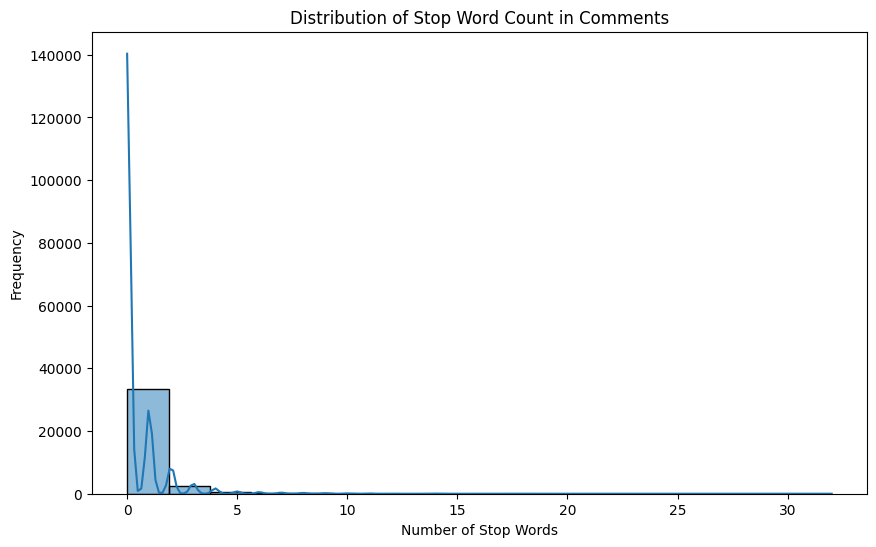

In [84]:
# Create a distribution plot (displot) for the 'num_stop_words' column
plt.figure(figsize=(10, 6))
sns.histplot(df['num_stop_words'], kde=True)

plt.title('Distribution of Stop Word Count in Comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')

plt.show()

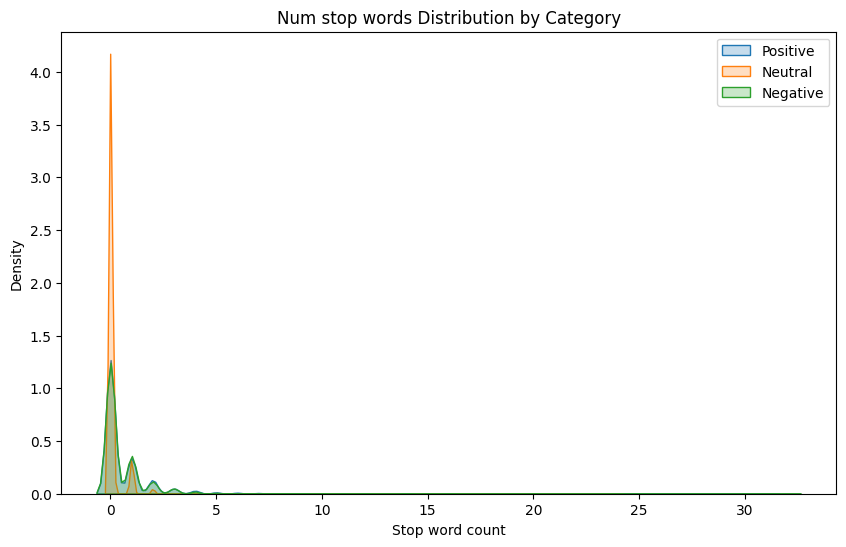

In [85]:
#showing more details view
# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['num_stop_words'], label='Positive', fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['num_stop_words'], label='Neutral', fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['num_stop_words'], label='Negative', fill=True)

# Add title and labels
plt.title('Num stop words Distribution by Category')
plt.xlabel('Stop word count')
plt.ylabel('Density')

# Add a legend
plt.legend()

<Axes: xlabel='category', ylabel='num_stop_words'>

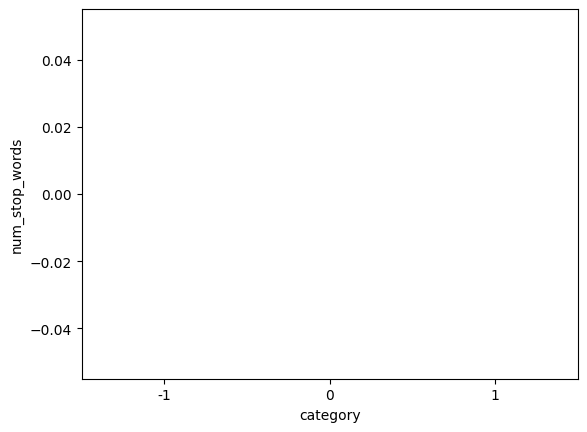

In [86]:
sns.barplot(df,x='category',y='num_stop_words',estimator='median')

/var/folders/5p/nn4hpk6x5t1f7dwq3g7hbc7m0000gn/T/ipykernel_4198/3998470117.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')


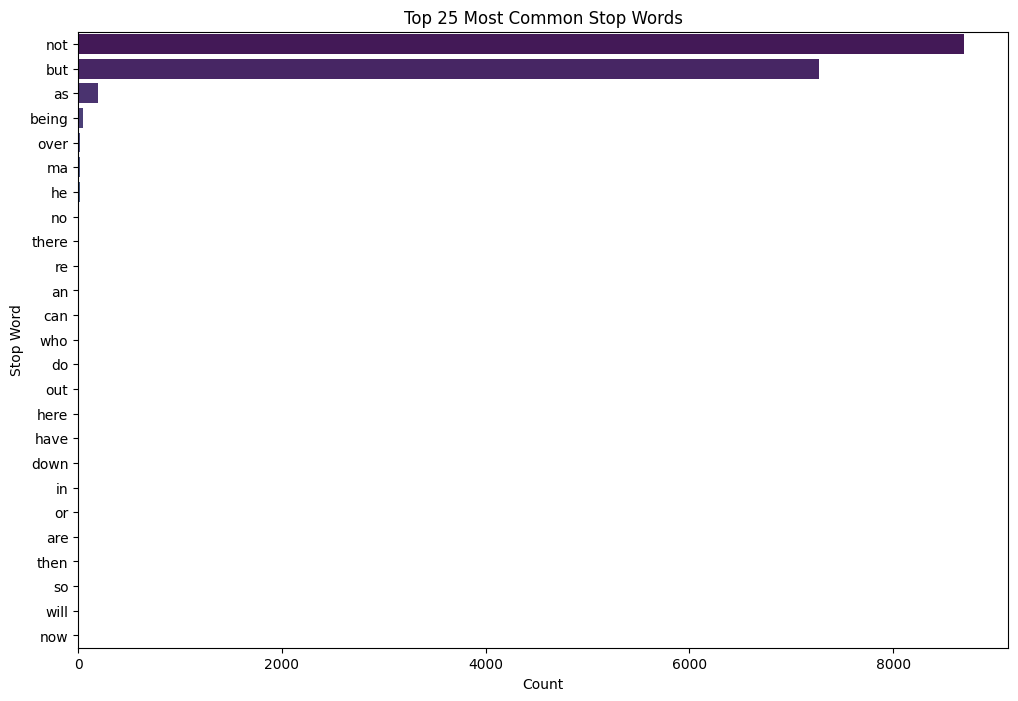

In [87]:
# Create a frequency distribution of stop words in the 'clean_comment' column
from collections import Counter

# Extract all stop words from the comments using the previously defined 'common_stopwords' .....সব কমেন্ট থেকে stopwords বের করে একটি list বানানো
all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]

# Count the most common stop words
most_common_stop_words = Counter(all_stop_words).most_common(25)

# Convert the most common stop words to a DataFrame for plotting
top_25_df = pd.DataFrame(most_common_stop_words, columns=['stop_word', 'count'])

# Create the barplot for the top 25 most common stop words
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')

plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')

plt.show()

In [88]:
df['num_chars']=df['clean_comment'].apply(len) #number of charecters in comment
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,26,0,196,0
1,buddhism much lot compatible christianity espe...,1,140,3,981,0
2,seriously say thing first get complex explain ...,-1,46,0,275,0
3,learned want teach different focus goal not wr...,0,15,1,101,0
4,benefit may want read living buddha living chr...,1,68,1,473,0


In [89]:
df['num_chars'].describe()

count    36794.000000
mean       135.331304
std        274.291889
min          0.000000
25%         28.000000
50%         60.000000
75%        136.000000
max       6583.000000
Name: num_chars, dtype: float64

In [90]:
# Combine all comments into one large string
all_text = ' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(
    char_frequency.items(),
    columns=['character', 'frequency']
).sort_values(by='frequency', ascending=False)

In [91]:
char_frequency_df['character'].values

array([' ', 'e', 'a', 'i', 't', 'n', 'o', 'r', 's', 'l', 'd', 'c', 'm',
       'p', 'u', 'g', 'h', 'y', 'b', 'k', 'w', 'f', 'v', 'j', 'x', '0',
       'z', 'q', '1', '2', '9', '5', '3', '4', '6', '7', '8'],
      dtype=object)

In [92]:
char_frequency_df.tail(50)

,character,frequency
6,,739312
10,e,495301
1,a,365598
3,i,343133
12,t,322905
9,n,317838
7,o,291373
8,r,268532
16,s,223448
4,l,217848


In [93]:
# Create a new column 'num_punctuation_chars' to count punctuation characters in each comment
df['num_punctuation_chars'] = df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}-'])
)

df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
22245,could full swing reportedly planning bring fam...,-1,17,0,108,0
10513,used live hellhole called louis boeing leaf ci...,-1,11,0,71,0
24629,lol worst thing reviewer saying game much like...,1,21,0,118,0
36201,not wanted wished youngster politics,1,5,1,36,0
4880,congress power pity always rule wonder done sh...,-1,26,0,187,0


In [94]:
df['num_punctuation_chars'].describe()

count    36794.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: num_punctuation_chars, dtype: float64

In [95]:
from sklearn.feature_extraction.text import CountVectorizer

/var/folders/5p/nn4hpk6x5t1f7dwq3g7hbc7m0000gn/T/ipykernel_4198/3221237636.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


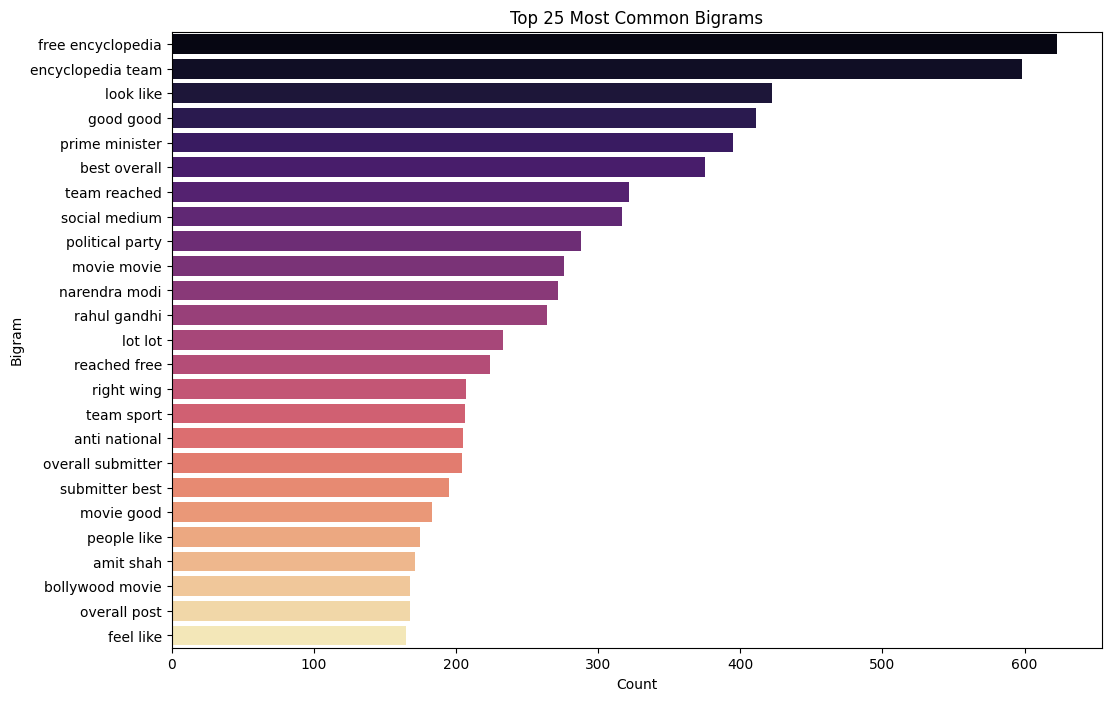

In [96]:
# Create a function to extract the top 25 bigrams
def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return words_freq[:n]


# Get the top 25 bigrams
top_25_bigrams = get_top_ngrams(df['clean_comment'], 25)

# Convert the bigrams into a DataFrame for plotting
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

# Plot the countplot for the top 25 bigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')

plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

/var/folders/5p/nn4hpk6x5t1f7dwq3g7hbc7m0000gn/T/ipykernel_4198/1735735001.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')


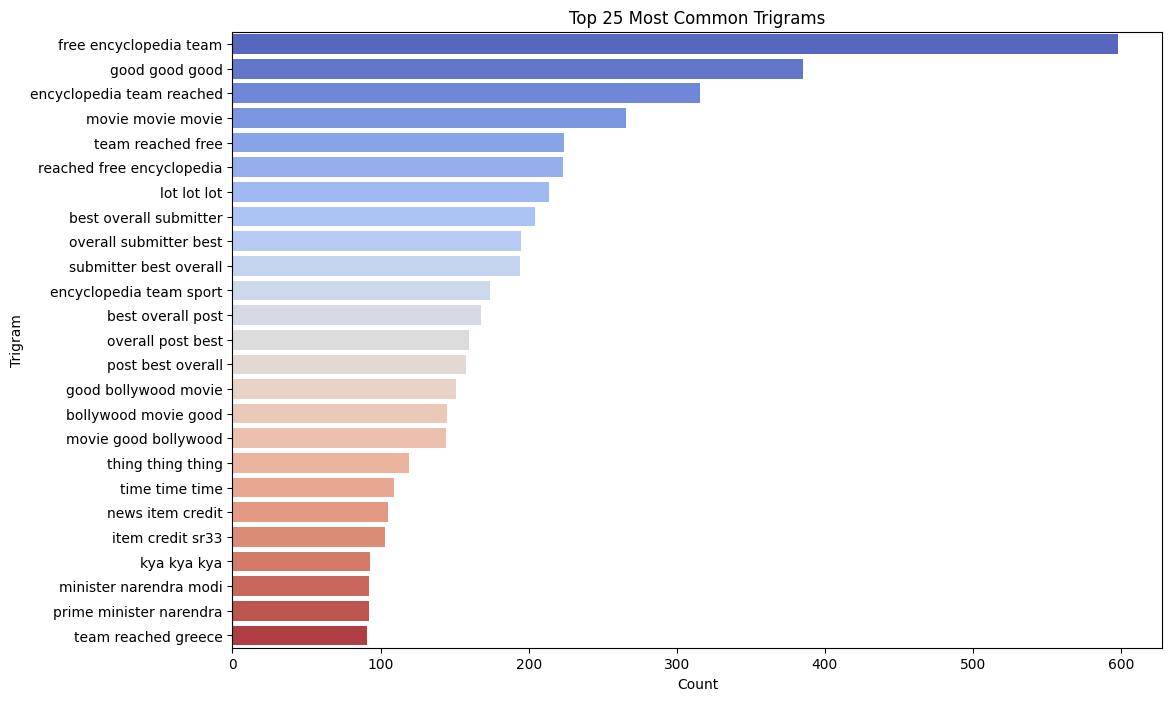

In [97]:
# Create a function to extract the top 25 trigrams
def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return words_freq[:n]


# Get the top 25 trigrams
top_25_trigrams = get_top_trigrams(df['clean_comment'], 25)

# Convert the trigrams into a DataFrame for plotting
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=['trigram', 'count'])

# Plot the countplot for the top 25 trigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')

plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [98]:
# Remove non-English characters from the 'clean_comment' column
# Keeping only standard English letters, digits, and common punctuation
import re

df['clean_comment'] = df['clean_comment'].apply(
    lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x))
)

# Combine all comments into one large string
all_text = ' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(
    char_frequency.items(),
    columns=['character', 'frequency']
).sort_values(by='frequency', ascending=False)

char_frequency_df

,character,frequency
6,,739312
10,e,495301
1,a,365598
3,i,343133
12,t,322905
9,n,317838
7,o,291373
8,r,268532
16,s,223448
4,l,217848


In [99]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,26,0,196,0
1,buddhism much lot compatible christianity espe...,1,140,3,981,0
2,seriously say thing first get complex explain ...,-1,46,0,275,0
3,learned want teach different focus goal not wr...,0,15,1,101,0
4,benefit may want read living buddha living chr...,1,68,1,473,0


In [100]:
from nltk.corpus import stopwords

# Defining stop words but keeping essential ones for sentiment analysis
stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}

# Remove stop words from 'clean_comment' column, retaining essential ones
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)

In [101]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,26,0,196,0
1,buddhism much lot compatible christianity espe...,1,140,3,981,0
2,seriously say thing first get complex explain ...,-1,46,0,275,0
3,learned want teach different focus goal not wr...,0,15,1,101,0
4,benefit may want read living buddha living chr...,1,68,1,473,0


In [102]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

# Define the lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rakibmahmud/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,26,0,196,0
1,buddhism much lot compatible christianity espe...,1,140,3,981,0
2,seriously say thing first get complex explain ...,-1,46,0,275,0
3,learned want teach different focus goal not wr...,0,15,1,101,0
4,benefit may want read living buddha living chr...,1,68,1,473,0


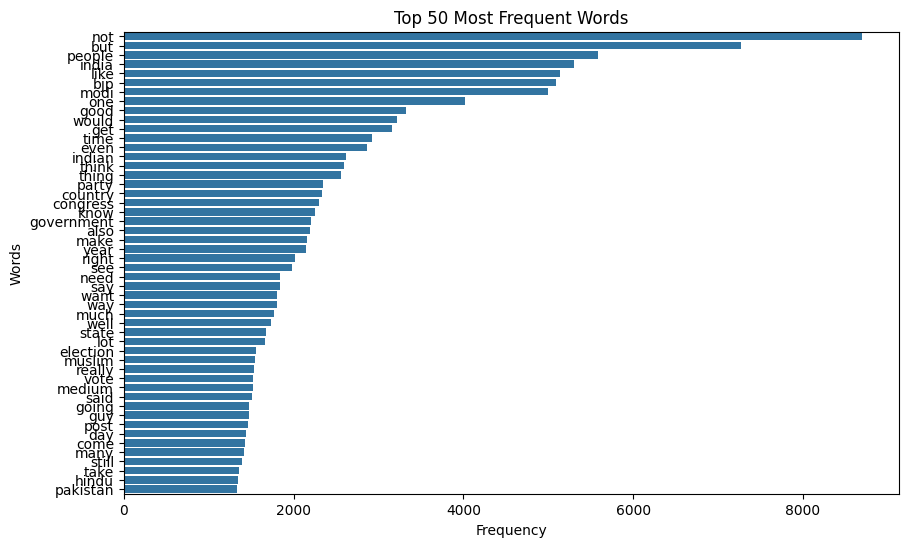

In [103]:
from collections import Counter

def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""

    # Flatten all words in the content column
    words = ' '.join(df['clean_comment']).split()

    # Get the top N most common words
    counter = Counter(words)
    most_common_words = counter.most_common(n)

    # Split the words and their counts for plotting
    words, counts = zip(*most_common_words)

    # Plot the top N words
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))

    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()


# Example usage
plot_top_n_words(df, n=50)

In [104]:
def plot_top_n_words_by_category(df, n=20, start=0):

    word_category_counts = {}

    for idx, row in df.iterrows():
        words = row['clean_comment'].split()
        category = row['category']

        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = {-1:0, 0:0, 1:0}

            word_category_counts[word][category] += 1

    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}

    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start:start+n]

    top_words = [word for word,_ in most_common_words]

    # ⭐ THIS LINE IS IMPORTANT
    word_labels = top_words

    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]

    plt.figure(figsize=(12,8))
    bar_width = 0.75

    plt.barh(word_labels, negative_counts, color='red', label='Negative (-1)', height=bar_width)
    plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Neutral (0)', height=bar_width)
    plt.barh(word_labels, positive_counts,left=[i+j for i,j in zip(negative_counts,neutral_counts)],color='green', label='Positive (1)', height=bar_width)

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories')
    plt.legend(title='Sentiment', loc='lower right')
    plt.gca().invert_yaxis()

    plt.show()

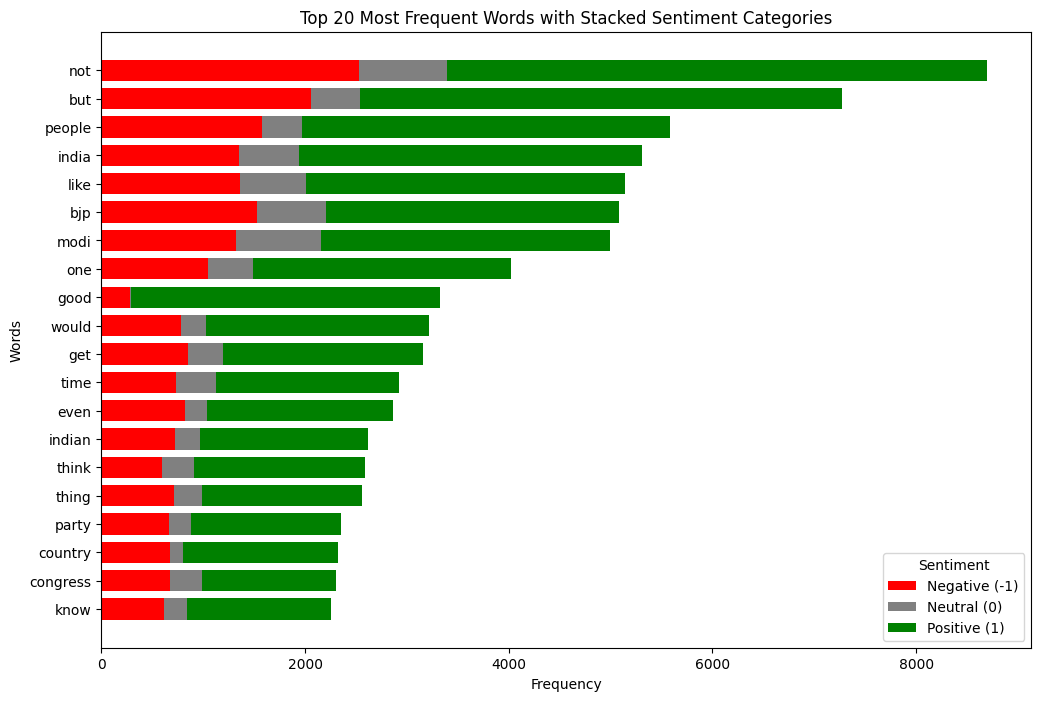

In [105]:
plot_top_n_words_by_category(df,n=20)

In [106]:
df.shape

(36794, 6)

In [107]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,26,0,196,0
1,buddhism much lot compatible christianity espe...,1,140,3,981,0
2,seriously say thing first get complex explain ...,-1,46,0,275,0
3,learned want teach different focus goal not wr...,0,15,1,101,0
4,benefit may want read living buddha living chr...,1,68,1,473,0


In [108]:
df.to_csv("processed_data.csv", index=False)

In [109]:
import pandas as pd
df1 = pd.read_csv("processed_data.csv")

In [110]:
df1.shape

(36794, 6)